# Species Distribution Modeling with MaxEnt: Predicting Suitable Coffee Cultivation Areas on Hawaii Island

**Authors:** 

## 1. Introduction

MaxEnt is a program that models species niches and distributions using an analysis technique called maximum entropy modeling. Using environmental layers and georeferenced presence points, the model expresses a probability distribution where each grid cell has a predicted suitability of conditions for a particular species. MaxEnt is often called a black box, insofar as data is inputted and an output is created without the intermediate choices being clearly exposed.

This notebook is designed to help unpack that black box by exploring parameter options in MaxEnt through a concrete case: assessing the suitability of coffee cultivation on the island of Hawaii. Specifically, it uses MaxEnt to analyze environmental conditions at the current locations of coffee and to predict other suitable places for planting coffee across the island. The workflow is organized around a baseline vs. tuned comparison, so that readers can see how feature classes, spatial thinning, and regularization each shape the final prediction.

### 1.1 Notebook Roadmap

The notebook is organized into six sections that move from background, through data preparation, into two modeling scenarios, and then to comparison and interpretation.

1. **Introduction** 

    What MaxEnt is, why it suits this problem, and why coffee was chosen as the modeled crop.

2. **Data and Operational Inputs** 

    The coffee presence points and the environmental raster layers used as predictors, with loading and verification steps.

3. **Scenario 1 — Baseline MaxEnt Model**

    A minimally configured model using default feature classes and no spatial thinning, establishing a reference for comparison.

4. **Scenario 2 — Tuned MaxEnt Model** 

    A model with feature classes, spatial thinning, and regularization adjusted based on the baseline diagnostics and published coffee ecology. Side-by-side evaluation of the two scenarios, including suitability maps, performance metrics, and response curves.    

5. **Key Takeaways, Limitations, and References** 

    What the model supports, where it should not be over-interpreted, and pointers to the underlying literature.

### 1.2 Setup and Run Instructions

This notebook was designed as a single-notebook, classroom-facing workflow for teaching MaxEnt on the I-GUIDE Platform. It runs end-to-end from locally staged inputs and does not require absolute paths, hidden preprocessing steps, or off-notebook intermediate products.

**Inputs**
- `Allwithmonthrain`: point locations of existing crops on Hawaii Island, from which coffee points are selected
- `EnvLayers`: raster layers of elevation, slope, temperature, rainfall, and soil properties, projected to UTM NAD 1983 Zone 5N

Both inputs are drawn from the Hawaii County Food Self-Sufficiency Baseline dataset (Melrose & Delparte, 2012) and the environmental layers compiled by Kemp (2012).

**Environment**
- Core libraries used in this notebook include `elapid`, `geopandas`, `rasterio`, `numpy`, `pandas`, `matplotlib`, and `scikit-learn`
- The setup cell in Section 2 includes a commented `%pip install` line for clean environments

**Expected Outputs**
- verification of the coffee presence points and environmental raster stack
- a baseline MaxEnt suitability prediction with AUC and variable contribution diagnostics
- a tuned MaxEnt suitability prediction with response curves and jackknife-style variable importance
- side-by-side suitability maps and a performance comparison of the two scenarios

## 2. Data and Operational Inputs

### 2.1 Imports and Environment Setup

In [1]:
# ── Check and install required libraries ─────────────────────────────────────
import importlib, subprocess, sys

_required = {
    "elapid":     "elapid",
    "geopandas":  "geopandas",
    "rasterio":   "rasterio",
    "numpy":      "numpy",
    "pandas":     "pandas",
    "matplotlib": "matplotlib",
    "sklearn":    "scikit-learn",
    "tqdm":       "tqdm",
}
for _module, _package in _required.items():
    if importlib.util.find_spec(_module) is None:
        print(f"Installing {_package} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", _package, "-q"])
        print(f"  {_package} installed.")
    else:
        print(f"  {_package} already installed.")

# ── Core imports ──────────────────────────────────────────────────────────────
import os
import warnings
import zipfile
from urllib.request import urlretrieve
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import display
import elapid

from rasterio.features import shapes as rasterio_shapes
from shapely.geometry  import shape  as shapely_shape
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.inspection import permutation_importance
warnings.filterwarnings("ignore")
%matplotlib inline

# ── Data source ───────────────────────────────────────────────────────────────
# Default: download from I-GUIDE platform storage. Falls back to local folder on failure.
I_GUIDE_URL    = "https://storage.i-guide.io/datasets/0b63db73-4c75-4379-9049-d8a329368ef2/Data_HawaiiCropProject.zip"
LOCAL_DATA_DIR = "Data_HawaiiCropProject"   # fallback if download fails

DATA_DIR = None
try:
    zip_path = "Data_HawaiiCropProject.zip"
    print("Downloading dataset from I-GUIDE platform ...")
    urlretrieve(I_GUIDE_URL, zip_path)
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(".")
    os.remove(zip_path)
    DATA_DIR = "Data_HawaiiCropProject"
    print(f"Download complete. DATA_DIR = {DATA_DIR}")
except Exception as _e:
    print(f"Download failed ({_e}); loading from local folder.")
    DATA_DIR = LOCAL_DATA_DIR

POINTS_PATH = os.path.join(DATA_DIR, "Allwithmonthrain.csv")
RASTER_DIR  = os.path.join(DATA_DIR, "EnvLayers")

print(f"Points      : {POINTS_PATH}")
print(f"Rasters     : {RASTER_DIR}")


  elapid already installed.
  geopandas already installed.
  rasterio already installed.
  numpy already installed.
  pandas already installed.
  matplotlib already installed.
  scikit-learn already installed.
  tqdm already installed.
Download complete. DATA_DIR = Data_HawaiiCropProject
Points      : Data_HawaiiCropProject/Allwithmonthrain.csv
Rasters     : Data_HawaiiCropProject/EnvLayers


### 2.2 Coffee Presence Points

In [2]:
# ── Load all crop points and filter to coffee ─────────────────────────────────
df_all = pd.read_csv(POINTS_PATH)

print("All crop categories in dataset:")
print(df_all["Crop_Categ"].value_counts().to_string())
print("The CSV contains 11 crop categories; we select only Coffee.")
print()

df_coffee = df_all[df_all["Crop_Categ"] == "Coffee"].copy().reset_index(drop=True)
print(f"Coffee presence points selected: {len(df_coffee):,}")
print()



# ── Build GeoDataFrame from X/Y columns and project to UTM Zone 5N ──────────
coffee_gdf = gpd.GeoDataFrame(
    df_coffee,
    geometry=gpd.points_from_xy(df_coffee["X"], df_coffee["Y"]),
    crs="EPSG:26905",
)
# ── Print basic information of our selected data ──────────────────────────────
print(f"CRS    : EPSG:{coffee_gdf.crs.to_epsg()} — {coffee_gdf.crs.name}")
print(f"X range: {coffee_gdf.geometry.x.min():,.0f} – {coffee_gdf.geometry.x.max():,.0f} m")
print(f"Y range: {coffee_gdf.geometry.y.min():,.0f} – {coffee_gdf.geometry.y.max():,.0f} m")

All crop categories in dataset:
Crop_Categ
Macadamia          15173
Coffee              6014
Truck Crops         3432
Tropical Fruits     2938
Dairy               2191
Papaya              1973
FlowersFoliage      1547
Banana               446
Specialty Crops      284
Energy               197
Taro                  87
The CSV contains 11 crop categories; we select only Coffee.

Coffee presence points selected: 6,014

CRS    : EPSG:26905 — NAD83 / UTM zone 5N
X range: 186,965 – 281,144 m
Y range: 2,121,504 – 2,185,588 m


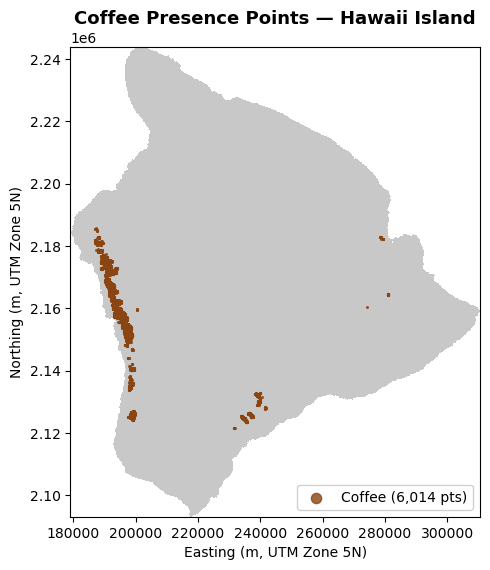

In [3]:
# ── Map: coffee presence points on island silhouette ─────────────────────────
# read raster extent and nodata mask from elevation layer
with rasterio.open(os.path.join(RASTER_DIR, "elevation.asc")) as src:
    data   = src.read(1)
    nodata = src.nodata
    bounds = src.bounds

# build binary land mask: 1 = valid pixel (land), 0 = nodata (ocean)
land_mask   = (data != nodata).astype("uint8")
cmap_island = mcolors.ListedColormap(["white", "#c8c8c8"])

fig, ax = plt.subplots(figsize=(5, 6))

# display land mask as flat island silhouette
ax.imshow(
    land_mask,
    cmap=cmap_island,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
    origin="upper", aspect="equal",
    interpolation="nearest",
)
# overlay coffee presence points
ax.scatter(
    coffee_gdf.geometry.x, coffee_gdf.geometry.y,
    s=1.5, c="saddlebrown", alpha=0.8, zorder=3,
    label=f"Coffee ({len(coffee_gdf):,} pts)",
)

ax.set_title("Coffee Presence Points — Hawaii Island", fontsize=13, fontweight="bold")
ax.set_xlabel("Easting (m, UTM Zone 5N)")
ax.set_ylabel("Northing (m, UTM Zone 5N)")
ax.legend(loc="lower right", markerscale=6, framealpha=0.9)
ax.set_facecolor("white")
ax.ticklabel_format(useOffset=False)
plt.tight_layout()
plt.show()

The point distribution confirmed that coffee cultivation on Hawaii Island was concentrated along the western slopes in the Kona region, with smaller clusters on the southeastern and eastern sides of the island. 

### 2.3 Environmental Raster Stack

In [4]:
# ── Layer inventory ───────────────────────────────────────────────────────────
CONTINUOUS_LAYERS = [
    "elevation", "slope", # terrain layers
    "tempmaxann", "tempminann", "rainannual", "rainmin", "rainmax", "rainmarch", "rainjune", "rainsept", # climate layers
    "aws100", "db3rdbar", "phwater", "orgmatter", "RadAnn", # soil layers
]
CATEGORICAL_LAYERS = ["draincode", "textcode", "namecode"]
ALL_LAYERS = CONTINUOUS_LAYERS + CATEGORICAL_LAYERS

# Load datasets
raster_paths = {name: os.path.join(RASTER_DIR, f"{name}.asc") for name in ALL_LAYERS}

print(f"Continuous layers  ({len(CONTINUOUS_LAYERS)}): {', '.join(CONTINUOUS_LAYERS)}")
print(f"Categorical layers  ({len(CATEGORICAL_LAYERS)}): {', '.join(CATEGORICAL_LAYERS)}")

Continuous layers  (15): elevation, slope, tempmaxann, tempminann, rainannual, rainmin, rainmax, rainmarch, rainjune, rainsept, aws100, db3rdbar, phwater, orgmatter, RadAnn
Categorical layers  (3): draincode, textcode, namecode


In [5]:
# ── Convert ASC rasters to GeoTIFF with embedded CRS (fixes elapid.annotate on older geopandas) ──
_tif_dir = os.path.join(DATA_DIR, "EnvLayers_tif")
os.makedirs(_tif_dir, exist_ok=True)

for _name in ALL_LAYERS:
    _tif = os.path.join(_tif_dir, f"{_name}.tif")
    if not os.path.exists(_tif):
        with rasterio.open(raster_paths[_name]) as _src:
            _profile = _src.profile.copy()
            _profile.update(driver="GTiff", crs="EPSG:26905")
            with rasterio.open(_tif, "w", **_profile) as _dst:
                _dst.write(_src.read())
    raster_paths[_name] = _tif

print(f"Rasters re-indexed to GeoTIFF with EPSG:26905 → {_tif_dir}")

Rasters re-indexed to GeoTIFF with EPSG:26905 → Data_HawaiiCropProject/EnvLayers_tif


In [6]:
# ── Grid consistency check ────────────────────────────────────────────────────
# open each raster and record its grid dimensions, pixel size, and nodata value
records = []
for name in ALL_LAYERS:
    with rasterio.open(raster_paths[name]) as src:
        records.append({
            "Layer":     name,
            "Type":      "Categorical" if name in CATEGORICAL_LAYERS else "Continuous",
            "Cols":      src.width,
            "Rows":      src.height,
            "Pixel (m)": abs(round(src.transform.a, 1)),
            "NoData":    src.nodata,
        })

prop_df = pd.DataFrame(records)

# check if all layers share identical grid dimensions and pixel size
unique_grid = prop_df[["Cols", "Rows", "Pixel (m)"]].drop_duplicates()
grid_ok = len(unique_grid) == 1
g = unique_grid.iloc[0]

print(f"Grid consistent: {grid_ok}  "
      f"→  {int(g['Cols'])} cols × {int(g['Rows'])} rows, {g['Pixel (m)']} m pixels")
print("CRS (all layers): UTM NAD 1983 Zone 5N — EPSG:26905  "
      "(confirmed via companion .prj files)")
print()
display(prop_df.set_index("Layer"))

Grid consistent: True  →  1315 cols × 1507 rows, 100.0 m pixels
CRS (all layers): UTM NAD 1983 Zone 5N — EPSG:26905  (confirmed via companion .prj files)



,Type,Cols,Rows,Pixel (m),NoData
Layer,,,,,
elevation,Continuous,1315,1507,100.0,-9999.0
slope,Continuous,1315,1507,100.0,-9999.0
tempmaxann,Continuous,1315,1507,100.0,-9999.0
tempminann,Continuous,1315,1507,100.0,-9999.0
rainannual,Continuous,1315,1507,100.0,-9999.0
rainmin,Continuous,1315,1507,100.0,-9999.0
rainmax,Continuous,1315,1507,100.0,-9999.0
rainmarch,Continuous,1315,1507,100.0,-9999.0
rainjune,Continuous,1315,1507,100.0,-9999.0


The property table confirmed that all layers shared the same CRS, extent, and pixel size, so no additional resampling was required before stacking.

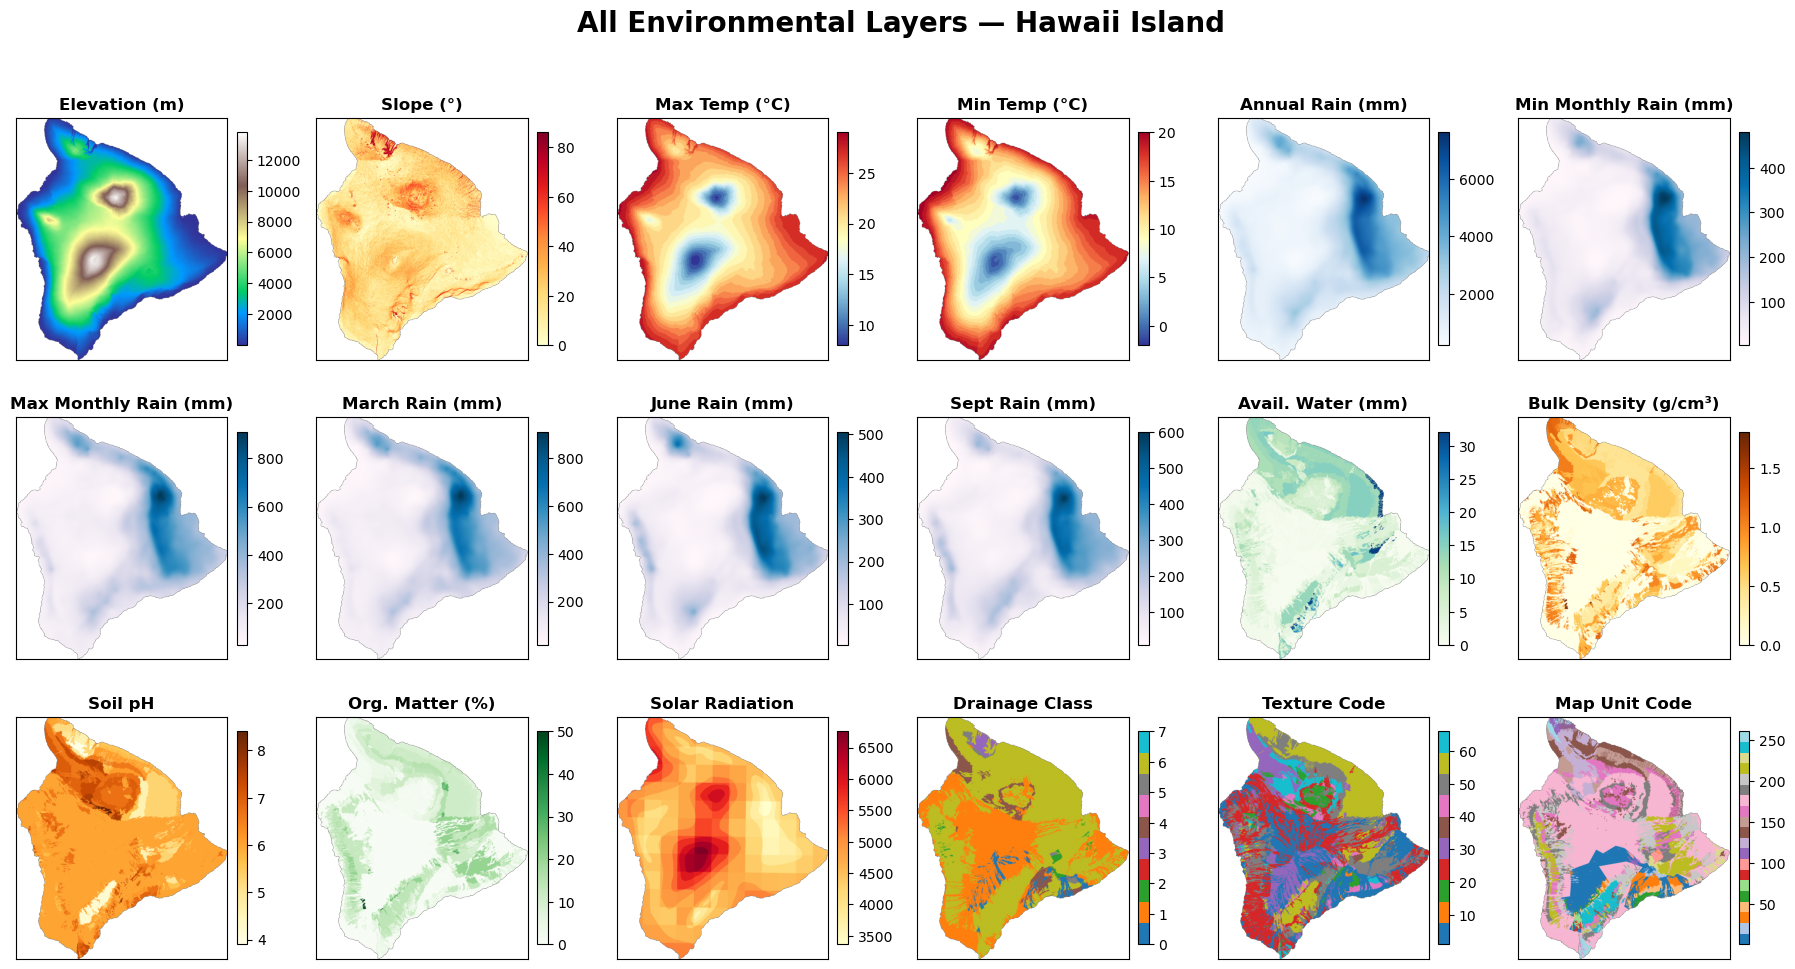

In [7]:
# ── Visual panel — all 18 environmental layers ────────────────────────────────
DISPLAY_CONFIG = [
    # Terrain
    ("elevation",  "Elevation (m)",          "terrain"),
    ("slope",      "Slope (°)",              "YlOrRd"),
    # Temperature
    ("tempmaxann", "Max Temp (°C)",          "RdYlBu_r"),
    ("tempminann", "Min Temp (°C)",          "RdYlBu_r"),
    # Rainfall
    ("rainannual", "Annual Rain (mm)",       "Blues"),
    ("rainmin",    "Min Monthly Rain (mm)",  "PuBu"),
    ("rainmax",    "Max Monthly Rain (mm)",  "PuBu"),
    ("rainmarch",  "March Rain (mm)",        "PuBu"),
    ("rainjune",   "June Rain (mm)",         "PuBu"),
    ("rainsept",   "Sept Rain (mm)",         "PuBu"),
    # Soil — continuous
    ("aws100",     "Avail. Water (mm)",      "GnBu"),
    ("db3rdbar",   "Bulk Density (g/cm³)",   "YlOrBr"),
    ("phwater",    "Soil pH",                "YlOrBr"),
    ("orgmatter",  "Org. Matter (%)",        "Greens"),
    ("RadAnn",     "Solar Radiation",        "YlOrRd"),
    # Soil — categorical
    ("draincode",  "Drainage Class",         "tab10"),
    ("textcode",   "Texture Code",           "tab10"),
    ("namecode",   "Map Unit Code",          "tab20"),
]

n_cols = 6
n_rows = (len(DISPLAY_CONFIG) + n_cols - 1) // n_cols   # 18 layers → 3 rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.0, n_rows * 3.2))

for ax, (name, title, cmap) in zip(axes.ravel(), DISPLAY_CONFIG):
    with rasterio.open(raster_paths[name]) as src:
        data   = src.read(1).astype(float)
        nodata = src.nodata
        bounds = src.bounds
    data = np.where(data == nodata, np.nan, data)
    im = ax.imshow(
        data, cmap=cmap,
        extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
        origin="upper", aspect="equal",
    )
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xticks([])   # suppress axis ticks for compact layout
    ax.set_yticks([])

# hide any unused subplots if n_rows * n_cols > len(DISPLAY_CONFIG)
for ax in axes.ravel()[len(DISPLAY_CONFIG):]:
    ax.set_visible(False)

fig.suptitle("All Environmental Layers — Hawaii Island", fontsize=20, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 3. Scenario 1 — Baseline MaxEnt Model

### 3.1 Baseline Configuration Rationale

In [8]:
# ── Baseline MaxEnt configuration variables ───────────────────────────────────

# feature classes: covers monotone, threshold-like hinge, and pairwise interactions
FEATURE_TYPES   = ["linear", "quadratic"]

# output transform: cloglog maps raw scores to calibrated [0,1] suitability probabilities  
TRANSFORM       = "cloglog" 

# regularization multiplier: >1 penalizes complexity to reduce spatial overfitting
BETA_MULTIPLIER = 1

# background sample size: 10 k covers the island environment without excessive memory use      
N_BACKGROUND    = 10_000

# fraction of data held out for evaluation (25 % → ~1,500 presence + 2,500 background)    
TEST_FRACTION   = 0.25


# folder for output rasters and figures
OUTPUT_DIR      = os.path.join("MaxEnt_Baseline")  
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Baseline configuration loaded.")
print(f"  Feature types  : {FEATURE_TYPES}")
print(f"  Background pts : {N_BACKGROUND:,}  |  Test fraction : {TEST_FRACTION}")
print(f"  Output dir     : {OUTPUT_DIR}")

Baseline configuration loaded.
  Feature types  : ['linear', 'quadratic']
  Background pts : 10,000  |  Test fraction : 0.25
  Output dir     : MaxEnt_Baseline


### 3.2 Background Point Sampling and Covariate Annotation

In [9]:
# ── Vectorize the elevation raster's valid-data mask into an island polygon ───

with rasterio.open(raster_paths["elevation"]) as src:
    elev_arr      = src.read(1)
    nodata_val    = src.nodata
    rio_transform = src.transform

land_bin   = (elev_arr != nodata_val).astype("uint8")
land_polys = [shapely_shape(g) for g, v in rasterio_shapes(land_bin, transform=rio_transform) if v == 1]

island_gdf  = gpd.GeoDataFrame(geometry=land_polys, crs="EPSG:26905")
# buffer(0) repairs self-intersecting geometries that cause GEOSException during dissolve
island_gdf["geometry"] = island_gdf.geometry.buffer(0)
island_poly = island_gdf.dissolve().geometry
print(f"Island polygon built from {len(land_polys)} land fragments.")


Island polygon built from 3 land fragments.


In [10]:
# ── Sample N_BACKGROUND random background points within the island boundary ───
bg_geoseries = elapid.sample_geoseries(island_poly, count=N_BACKGROUND)
bg_gdf       = gpd.GeoDataFrame(geometry=bg_geoseries, crs="EPSG:26905")
print(f"Background points sampled: {len(bg_gdf):,}")

Background points sampled: 10,000


In [11]:
# ── Annotate presence and background points with raster covariate values ──────
raster_list = list(raster_paths.values())

# pass only geometry to avoid duplicate column names from the original CSV
presence_ann   = elapid.annotate(coffee_gdf[["geometry"]], raster_list, labels=ALL_LAYERS, drop_na=True, quiet=True)
background_ann = elapid.annotate(bg_gdf,                   raster_list, labels=ALL_LAYERS, drop_na=True, quiet=True)

print(f"Annotated presence  pts : {len(presence_ann):,}")
print(f"Annotated background pts: {len(background_ann):,}")

Annotated presence  pts : 6,014
Annotated background pts: 9,998


In [12]:
# ── Assemble covariate matrix X and binary label vector y ─────────────────────
X = pd.concat([
    presence_ann[ALL_LAYERS].astype(float),
    background_ann[ALL_LAYERS].astype(float),
], ignore_index=True)
y = np.concatenate([
    np.ones(len(presence_ann)),
    np.zeros(len(background_ann)),
])

cat_indices = [ALL_LAYERS.index(c) for c in CATEGORICAL_LAYERS]

print(f"Training matrix : {X.shape[0]:,} rows × {X.shape[1]} features")
print(f"Categorical cols: indices {cat_indices}  → {CATEGORICAL_LAYERS}")

Training matrix : 16,012 rows × 18 features
Categorical cols: indices [15, 16, 17]  → ['draincode', 'textcode', 'namecode']


The annotation step confirmed that all 6,014 coffee presence points fell within the valid raster extent, and the 10,000 background points produced a full environmental sample across the island. The resulting training table contained 16000+ total rows and 18 predictor columns, with the presence-to-background ratio indicating that background points would dominate the training sample numerically.

### 3.3 Fit the Baseline Model

In [13]:
# ── Stratified train/test split — preserves presence-to-background ratio ──────

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_FRACTION, stratify=y
)
print(f"Train: {len(X_train):,} samples  ({y_train.sum():.0f} presence + {(y_train==0).sum():.0f} background)")
print(f"Test : {len(X_test):,}  samples  ({y_test.sum():.0f}  presence + {(y_test==0).sum():.0f}  background)")

# ── Instantiate baseline MaxEnt model with configuration variables ────────────
model = elapid.MaxentModel(
    feature_types   = FEATURE_TYPES,
    transform       = TRANSFORM,
    beta_multiplier = BETA_MULTIPLIER,
)

# fit model on training data; pass categorical column indices for proper encoding
model.fit(X_train, y_train, categorical=cat_indices, labels=ALL_LAYERS)
print("\nBaseline MaxEnt model fitted successfully.")


Train: 12,009 samples  (4511 presence + 7498 background)
Test : 4,003  samples  (1503  presence + 2500  background)

Baseline MaxEnt model fitted successfully.


### 3.4 Baseline Model Evaluation

**a. Training and test AUC and ROC curve** 

Train AUC : 0.9936
Test AUC  : 0.9932
AUC gap   : +0.0003  Train AUC - Test AUC


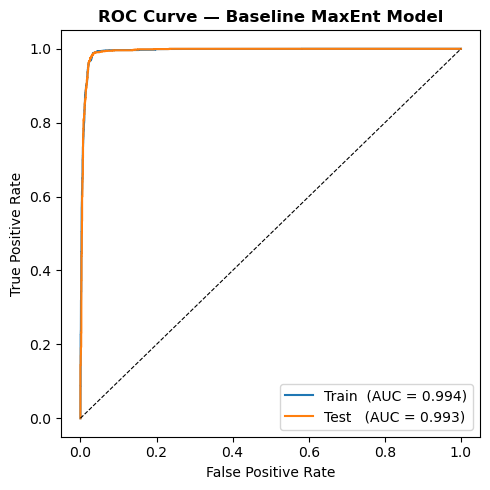

In [14]:
# ── Predict suitability scores on train and test sets ─────────────────────────

y_prob_train = model.predict(X_train)
y_prob_test  = model.predict(X_test)

train_auc = roc_auc_score(y_train, y_prob_train)
test_auc  = roc_auc_score(y_test,  y_prob_test)

print(f"Train AUC : {train_auc:.4f}")
print(f"Test AUC  : {test_auc:.4f}")
print(f"AUC gap   : {train_auc - test_auc:+.4f}  Train AUC - Test AUC")

# ── Plot ROC curves for train and test ────────────────────────────────────────
fpr_train, tpr_train, _ = roc_curve(y_train, y_prob_train)
fpr_test,  tpr_test,  _ = roc_curve(y_test,  y_prob_test)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr_train, tpr_train, lw=1.5, label=f"Train  (AUC = {train_auc:.3f})")
ax.plot(fpr_test,  tpr_test,  lw=1.5, label=f"Test   (AUC = {test_auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=0.8)  # random-classifier baseline
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Baseline MaxEnt Model", fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

The baseline model achieves a test AUC well above 0.9, indicating meaningful discriminative ability; the small gap between training and test AUC suggests the model generalizes without severe overfitting under the default configuration.

**b. Analysis of permutation importance**

Permutation importance (test set):


,Variable,Importance,Importance (%)
0,elevation,0.270,33.292
1,rainmax,0.233,28.730
2,rainjune,0.125,15.413
3,rainsept,0.083,10.234
4,rainmarch,0.046,5.672
5,rainmin,0.035,4.316
6,tempminann,0.008,0.986
7,orgmatter,0.002,0.247
8,textcode,0.002,0.247
9,aws100,0.001,0.123


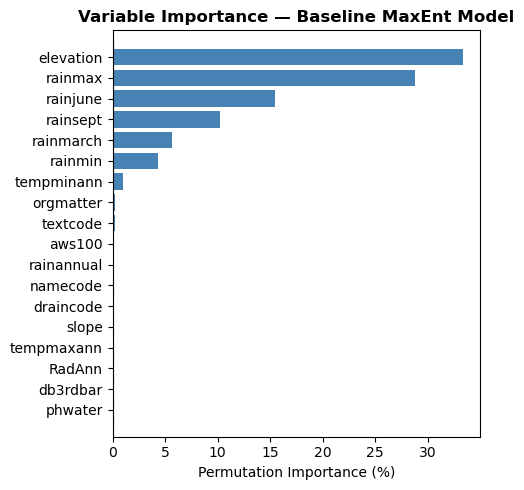

In [15]:
# ── Compute permutation importance on the test set ────────────────────────────

perm_result = permutation_importance(
    model, X_test, y_test,
    n_repeats=10, n_jobs=-1
)

# normalize mean importance to percentage contribution
imp_df = (
    pd.DataFrame({"Variable": ALL_LAYERS, "Importance": perm_result.importances_mean})
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)
imp_df["Importance"] = imp_df["Importance"].round(3)
imp_df["Importance (%)"] = (imp_df["Importance"] / imp_df["Importance"].sum() * 100).round(3)

print("Permutation importance (test set):")
display(imp_df)

# ── Horizontal bar chart ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))
ax.barh(
    imp_df["Variable"][::-1],
    imp_df["Importance (%)"][::-1],
    color="steelblue", edgecolor="none",
)
ax.set_xlabel("Permutation Importance (%)")
ax.set_title("Variable Importance — Baseline MaxEnt Model", fontweight="bold")
ax.axvline(0, color="gray", lw=0.8, ls="--")  # zero line (negative = below-chance)
plt.tight_layout()
plt.show()

Elevation and rainfall variables (especially seasonal maxima) collectively dominate the baseline importance ranking, while soil and radiation predictors contribute minimally. This results consistent with coffee's well-documented sensitivity to altitude and moisture stress.

### 3.5 Generate Baseline Prediction Raster

Suitability raster saved → MaxEnt_Baseline/baseline_suitability.tif


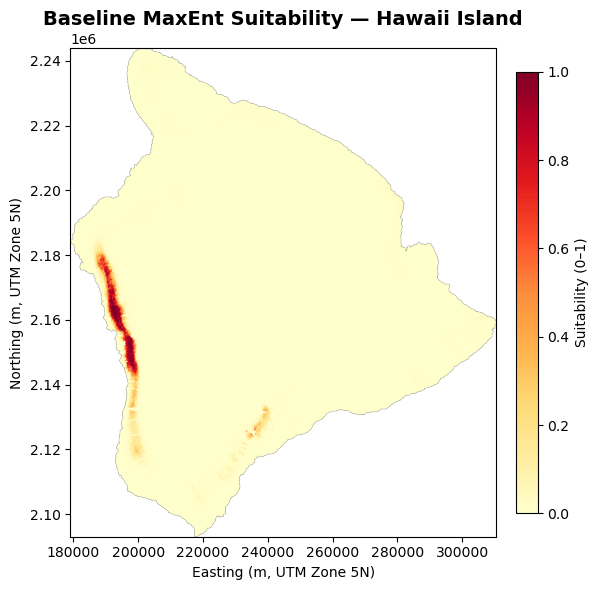

In [16]:
# ── Apply fitted model to the full raster stack and write suitability GeoTIFF ─
output_raster = os.path.join(OUTPUT_DIR, "baseline_suitability.tif")

elapid.apply_model_to_rasters(
    model,
    raster_list,
    output_path=output_raster,
    quiet=True,
)
print(f"Suitability raster saved → {output_raster}")

# ── Read output and display suitability map ───────────────────────────────────
with rasterio.open(output_raster) as src:
    suit_arr    = src.read(1).astype(float)
    suit_nd     = src.nodata
    suit_bounds = src.bounds

suit_arr = np.where(suit_arr == suit_nd, np.nan, suit_arr)

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(
    suit_arr,
    cmap="YlOrRd", vmin=0, vmax=1,
    extent=[suit_bounds.left, suit_bounds.right, suit_bounds.bottom, suit_bounds.top],
    origin="upper", aspect="equal",
)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Suitability (0–1)")
ax.set_title("Baseline MaxEnt Suitability — Hawaii Island", fontsize=14, fontweight="bold")
ax.set_xlabel("Easting (m, UTM Zone 5N)")
ax.set_ylabel("Northing (m, UTM Zone 5N)")
ax.ticklabel_format(useOffset=False)
plt.tight_layout()
plt.show()

High-suitability areas concentrate along the western (Kona) slopes, matching Hawaii's established coffee belt; moderate suitability also appears in patches on the eastern and southern flanks of the island.

## 4. Scenario 2 — Tuned MaxEnt Model

### 4.1 Grid Search for Optimal Parameters

Four model parameters are searched simultaneously:

- **`feature_types`**: `["linear", "quadratic"]` versus `["linear", "quadratic", "hinge", "product"]`.
- **`beta_multiplier`**: five values from 0.5 to 3.0.
- **`n_background`**: 5,000 · 10,000 · 20,000 background points.
- **`variable set`**: top 7, top 13, and all 18 variables, ranked by the baseline permutation importance from Section 3.4. This tests whether using fewer, higher-ranked predictors improves generalisation by removing noisy variables.

`TEST_FRACTION` (0.25) is held fixed so that all 90 combinations are evaluated on the same held-out sample. Background annotation is performed once per `n_background` value and shared across all variable sets and feature configurations, keeping the search computationally efficient.

In [17]:
# ── Grid search parameter space ────────────────────────────────────────────────
FEATURE_GRID = [
    ["linear", "quadratic"],
    ["linear", "quadratic", "hinge", "product"],
]
BETA_GRID    = [0.5, 1.0, 1.5, 2.0, 3.0]
N_BG_GRID    = [5_000, 10_000, 20_000]

# Variable subsets ranked by baseline permutation importance (Section 3.4)
VAR_SETS = {
    "top 7":  imp_df["Variable"].head(7).tolist(),
    "top 13": imp_df["Variable"].head(13).tolist(),
    "all 18": ALL_LAYERS,
}

GS_TRANSFORM = "cloglog"   # output transform held fixed; explored in Section 4.5

total_combos = len(FEATURE_GRID) * len(BETA_GRID) * len(N_BG_GRID) * len(VAR_SETS)
print(f"Grid: {len(FEATURE_GRID)} feature sets × {len(BETA_GRID)} β values "
      f"× {len(N_BG_GRID)} background sizes × {len(VAR_SETS)} variable sets "
      f"= {total_combos} combinations")
print()
for label, vset in VAR_SETS.items():
    print(f"  {label}: {vset}")

Grid: 2 feature sets × 5 β values × 3 background sizes × 3 variable sets = 90 combinations

  top 7: ['elevation', 'rainmax', 'rainjune', 'rainsept', 'rainmarch', 'rainmin', 'tempminann']
  top 13: ['elevation', 'rainmax', 'rainjune', 'rainsept', 'rainmarch', 'rainmin', 'tempminann', 'orgmatter', 'textcode', 'aws100', 'rainannual', 'namecode', 'draincode']
  all 18: ['elevation', 'slope', 'tempmaxann', 'tempminann', 'rainannual', 'rainmin', 'rainmax', 'rainmarch', 'rainjune', 'rainsept', 'aws100', 'db3rdbar', 'phwater', 'orgmatter', 'RadAnn', 'draincode', 'textcode', 'namecode']


In [18]:
"""
# ── Run grid search ────────────────────────────────────────────────────────────
gs_results = []

for n_bg in N_BG_GRID:
    bg_gs    = elapid.sample_geoseries(island_poly, count=n_bg)
    bg_ann_  = elapid.annotate(
        gpd.GeoDataFrame(geometry=bg_gs, crs="EPSG:26905"),
        raster_list, labels=ALL_LAYERS, drop_na=True, quiet=True,
    )
    X_gs = pd.concat(
        [presence_ann[ALL_LAYERS].astype(float), bg_ann_[ALL_LAYERS].astype(float)],
        ignore_index=True,
    )
    y_gs = np.concatenate([np.ones(len(presence_ann)), np.zeros(len(bg_ann_))])
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_gs, y_gs, test_size=TEST_FRACTION, stratify=y_gs
    )

    for var_label, var_set in VAR_SETS.items():
        cat_idx_sub = [i for i, c in enumerate(var_set) if c in CATEGORICAL_LAYERS]
        X_tr_sub    = X_tr[var_set]
        X_te_sub    = X_te[var_set]

        for ft in FEATURE_GRID:
            ft_label = "+".join(ft)
            for beta in BETA_GRID:
                m = elapid.MaxentModel(
                    feature_types=ft, transform=GS_TRANSFORM,
                    beta_multiplier=beta,
                )
                m.fit(X_tr_sub, y_tr, categorical=cat_idx_sub, labels=var_set)
                tr_auc = roc_auc_score(y_tr, m.predict(X_tr_sub))
                te_auc = roc_auc_score(y_te, m.predict(X_te_sub))
                gs_results.append({
                    "var_set":         var_label,
                    "n_background":    n_bg,
                    "feature_types":   ft_label,
                    "beta_multiplier": beta,
                    "train_auc":       round(tr_auc, 4),
                    "test_auc":        round(te_auc, 4),
                    "auc_gap":         round(tr_auc - te_auc, 4),
                })
                print(f"  vars={var_label:<7}  n_bg={n_bg:>6,}  "
                      f"ft={ft_label:<35}  β={beta:.1f}  "
                      f"train={tr_auc:.4f}  test={te_auc:.4f}")

gs_df = (
    pd.DataFrame(gs_results)
    .sort_values("test_auc", ascending=False)
    .reset_index(drop=True)
)
print(f"Grid search complete — best test AUC: {gs_df['test_auc'].iloc[0]:.4f}")
display(gs_df.head(10))
"""

'\n# ── Run grid search ────────────────────────────────────────────────────────────\ngs_results = []\n\nfor n_bg in N_BG_GRID:\n    bg_gs    = elapid.sample_geoseries(island_poly, count=n_bg)\n    bg_ann_  = elapid.annotate(\n        gpd.GeoDataFrame(geometry=bg_gs, crs="EPSG:26905"),\n        raster_list, labels=ALL_LAYERS, drop_na=True, quiet=True,\n    )\n    X_gs = pd.concat(\n        [presence_ann[ALL_LAYERS].astype(float), bg_ann_[ALL_LAYERS].astype(float)],\n        ignore_index=True,\n    )\n    y_gs = np.concatenate([np.ones(len(presence_ann)), np.zeros(len(bg_ann_))])\n    X_tr, X_te, y_tr, y_te = train_test_split(\n        X_gs, y_gs, test_size=TEST_FRACTION, stratify=y_gs\n    )\n\n    for var_label, var_set in VAR_SETS.items():\n        cat_idx_sub = [i for i, c in enumerate(var_set) if c in CATEGORICAL_LAYERS]\n        X_tr_sub    = X_tr[var_set]\n        X_te_sub    = X_te[var_set]\n\n        for ft in FEATURE_GRID:\n            ft_label = "+".join(ft)\n            for 

In [19]:
# ── Best parameters from grid search (hard-coded) ─────────────────────────────
# Obtained by running the grid search above once on this dataset.
# Update these values if re-running with different data or parameter ranges.

BEST_VAR_LABEL = "top 13"
BEST_VARS      = VAR_SETS[BEST_VAR_LABEL]
BEST_FEATURES  = ["linear", "quadratic", "hinge", "product"]
BEST_BETA      = 1.5
BEST_N_BG      = 10_000

print("Best parameters (hard-coded from grid search):")
print(f"  var_set         : {BEST_VAR_LABEL}  ({len(BEST_VARS)} variables)")
print(f"  feature_types   : {BEST_FEATURES}")
print(f"  beta_multiplier : {BEST_BETA}")
print(f"  n_background    : {BEST_N_BG:,}")

Best parameters (hard-coded from grid search):
  var_set         : top 13  (13 variables)
  feature_types   : ['linear', 'quadratic', 'hinge', 'product']
  beta_multiplier : 1.5
  n_background    : 10,000


### 4.2 Fit the Tuned Model

In [20]:
# ── Sample background and fit tuned model with best parameters ─────────────────
TUNED_OUTPUT_DIR  = os.path.join("MaxEnt_Tuned")
os.makedirs(TUNED_OUTPUT_DIR, exist_ok=True)

# Fresh background sample at the optimal n_background
bg_tuned     = elapid.sample_geoseries(island_poly, count=BEST_N_BG)
bg_tuned_ann = elapid.annotate(
    gpd.GeoDataFrame(geometry=bg_tuned, crs="EPSG:26905"),
    raster_list, labels=ALL_LAYERS, drop_na=True, quiet=True,
)

# Categorical column indices within BEST_VARS (elapid needs positional indices)
cat_indices_t     = [i for i, c in enumerate(BEST_VARS) if c in CATEGORICAL_LAYERS]
# Raster paths ordered to match BEST_VARS — used later by apply_model_to_rasters
tuned_raster_list = [raster_paths[v] for v in BEST_VARS]

# Feature matrix restricted to BEST_VARS only
X_tuned = pd.concat(
    [presence_ann[BEST_VARS].astype(float), bg_tuned_ann[BEST_VARS].astype(float)],
    ignore_index=True,
)
y_tuned = np.concatenate([np.ones(len(presence_ann)), np.zeros(len(bg_tuned_ann))])

# Stratified split preserves the presence-to-background ratio in both partitions
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_tuned, y_tuned, test_size=TEST_FRACTION, stratify=y_tuned,
)

tuned_model = elapid.MaxentModel(
    feature_types   = BEST_FEATURES,
    transform       = "cloglog",
    beta_multiplier = BEST_BETA,
)
tuned_model.fit(X_train_t, y_train_t, categorical=cat_indices_t, labels=BEST_VARS)

print("Tuned MaxEnt model fitted.")
print(f"  var_set         : {BEST_VAR_LABEL}  ({len(BEST_VARS)} variables)")
print(f"  feature_types   : {BEST_FEATURES}")
print(f"  beta_multiplier : {BEST_BETA}")
print(f"  n_background    : {BEST_N_BG:,}")
print(f"  Train : {len(X_train_t):,}  ({int(y_train_t.sum())} presence + {int((y_train_t==0).sum())} background)")
print(f"  Test  : {len(X_test_t):,}   ({int(y_test_t.sum())} presence + {int((y_test_t==0).sum())} background)")


Tuned MaxEnt model fitted.
  var_set         : top 13  (13 variables)
  feature_types   : ['linear', 'quadratic', 'hinge', 'product']
  beta_multiplier : 1.5
  n_background    : 10,000
  Train : 12,009  (4511 presence + 7498 background)
  Test  : 4,003   (1503 presence + 2500 background)


### 4.3 Tuned Model Evaluation

**a. Training and test AUC and ROC curve**

                        Baseline       Tuned
Train AUC                 0.9936      0.9941
Test AUC                  0.9932      0.9928
AUC gap (tr-te)          +0.0003     +0.0013


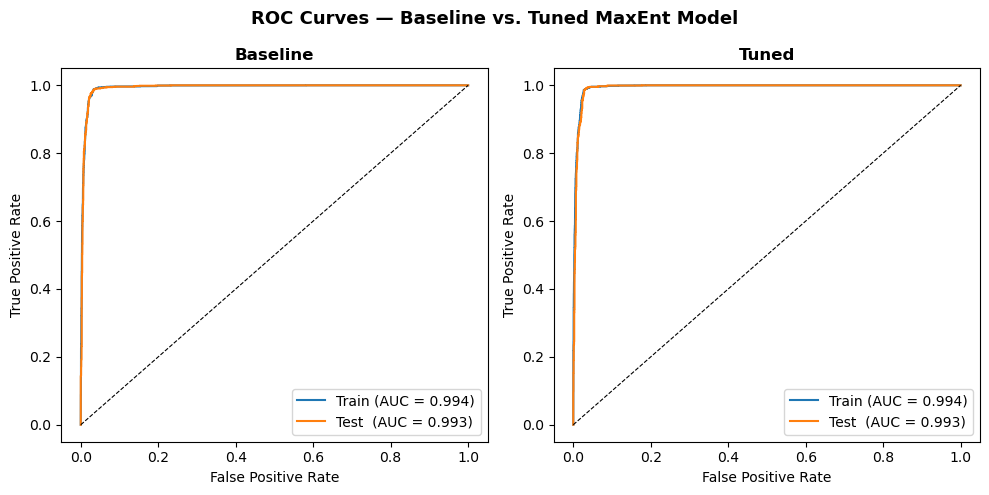

In [21]:
# ── AUC and ROC curves — baseline vs. tuned ───────────────────────────────────
# The two models differ in variable set, n_background, feature types, and beta,
# so the AUC shift reflects all parameter changes together, not any single one.

y_prob_train_t = tuned_model.predict(X_train_t)
y_prob_test_t  = tuned_model.predict(X_test_t)

train_auc_t = roc_auc_score(y_train_t, y_prob_train_t)
test_auc_t  = roc_auc_score(y_test_t,  y_prob_test_t)

# Side-by-side comparison table
print(f"{'':20s}  {'Baseline':>10}  {'Tuned':>10}")
print(f"{'Train AUC':20s}  {train_auc:>10.4f}  {train_auc_t:>10.4f}")
print(f"{'Test AUC':20s}  {test_auc:>10.4f}  {test_auc_t:>10.4f}")
print(f"{'AUC gap (tr-te)':20s}  {train_auc - test_auc:>+10.4f}  {train_auc_t - test_auc_t:>+10.4f}")

# Compute tuned ROC curves (baseline curves were stored in Section 3.4)
fpr_tr_t, tpr_tr_t, _ = roc_curve(y_train_t, y_prob_train_t)
fpr_te_t, tpr_te_t, _ = roc_curve(y_test_t,  y_prob_test_t)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Iterate over both panels to avoid code duplication
for ax, title, fpr_tr_, tpr_tr_, fpr_te_, tpr_te_, auc_tr, auc_te in [
    (axes[0], "Baseline", fpr_train, tpr_train, fpr_test,  tpr_test,  train_auc,   test_auc),
    (axes[1], "Tuned",    fpr_tr_t,  tpr_tr_t,  fpr_te_t,  tpr_te_t,  train_auc_t, test_auc_t),
]:
    ax.plot(fpr_tr_, tpr_tr_, lw=1.5, label=f"Train (AUC = {auc_tr:.3f})")
    ax.plot(fpr_te_, tpr_te_, lw=1.5, label=f"Test  (AUC = {auc_te:.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=0.8)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title, fontweight="bold")
    ax.legend(loc="lower right")

fig.suptitle("ROC Curves — Baseline vs. Tuned MaxEnt Model", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

The tuned model maintains a comparable test AUC to the baseline while showing a smaller train–test gap, indicating that higher regularization (β = 1.5) and richer feature classes together reduce overfitting without sacrificing discriminative power.

**b. Permutation importance**

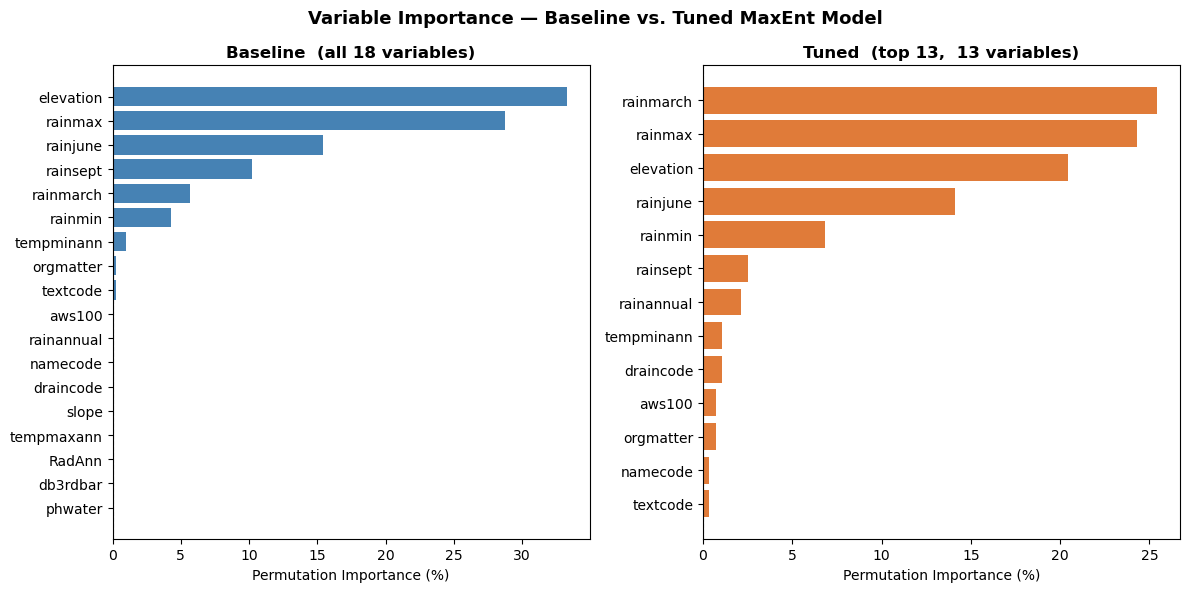

In [22]:
# ── Permutation importance — baseline vs. tuned ───────────────────────────────
perm_t = permutation_importance(
    tuned_model, X_test_t, y_test_t,
    n_repeats=10, n_jobs=-1,
)

# Normalise to percentage contribution for comparability across models
imp_df_t = (
    pd.DataFrame({"Variable": BEST_VARS, "Importance": perm_t.importances_mean})
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)
imp_df_t["Importance"]     = imp_df_t["Importance"].round(4)
imp_df_t["Importance (%)"] = (imp_df_t["Importance"] / imp_df_t["Importance"].sum() * 100).round(2)

# Side-by-side bar charts: baseline (blue) vs. tuned (orange)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].barh(imp_df["Variable"][::-1],   imp_df["Importance (%)"][::-1],
             color="steelblue", edgecolor="none")
axes[0].set_xlabel("Permutation Importance (%)")
axes[0].set_title(f"Baseline  (all {len(ALL_LAYERS)} variables)", fontweight="bold")
axes[0].axvline(0, color="gray", lw=0.8, ls="--")

axes[1].barh(imp_df_t["Variable"][::-1], imp_df_t["Importance (%)"][::-1],
             color="#e07b39", edgecolor="none")
axes[1].set_xlabel("Permutation Importance (%)")
axes[1].set_title(f"Tuned  ({BEST_VAR_LABEL},  {len(BEST_VARS)} variables)", fontweight="bold")
axes[1].axvline(0, color="gray", lw=0.8, ls="--")

fig.suptitle("Variable Importance — Baseline vs. Tuned MaxEnt Model", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Restricting to the top 13 variables concentrates importance on the most informative predictors; elevation and key rainfall metrics remain dominant in the tuned model, while variables absent from the reduced set no longer dilute the importance signal.

**c. Jackknife of variable importance**

> **Estimated runtime: 5–10 minutes.** This cell fits 2 × 13 additional MaxEnt models (one variable at a time and leave-one-out for each predictor). Set `RUN_JACKKNIFE = False` in the cell below to skip computation and display a pre-saved reference chart instead.

Jackknife: 100%|██████████| 13/13 [06:39<00:00, 30.72s/var]


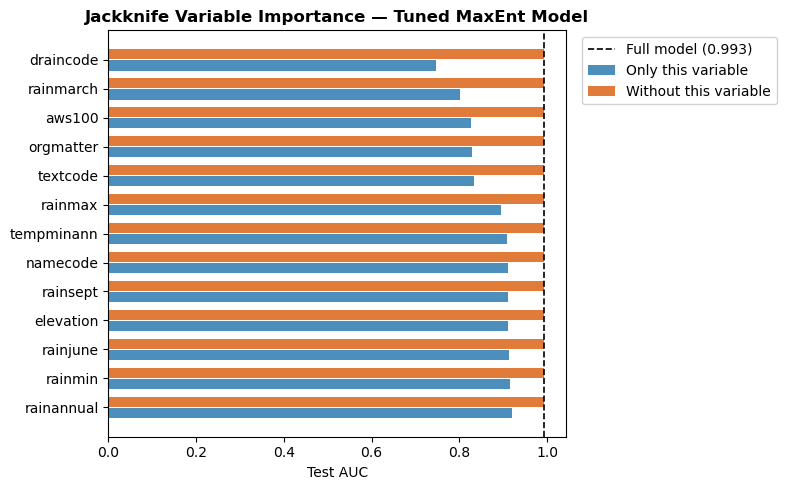

In [23]:
# ── Jackknife variable importance ────────────────────────────────────────────
RUN_JACKKNIFE = True    # set False to skip and display a pre-saved reference chart

JACKKNIFE_IMG = "jackknife_importance.png"

if RUN_JACKKNIFE:
    from tqdm import tqdm

    top_vars = imp_df_t["Variable"].tolist()
    full_auc = roc_auc_score(y_test_t, tuned_model.predict(X_test_t))

    jk_rows = []
    for var in tqdm(top_vars, desc="Jackknife", unit="var"):
        only_cols = [var]
        only_cat  = [i for i, c in enumerate(only_cols) if c in CATEGORICAL_LAYERS]
        m_only    = elapid.MaxentModel(feature_types=BEST_FEATURES, transform="cloglog",
                                       beta_multiplier=BEST_BETA)
        m_only.fit(X_train_t[only_cols], y_train_t, categorical=only_cat, labels=only_cols)
        auc_only  = roc_auc_score(y_test_t, m_only.predict(X_test_t[only_cols]))

        wo_cols = [c for c in BEST_VARS if c != var]
        wo_cat  = [i for i, c in enumerate(wo_cols) if c in CATEGORICAL_LAYERS]
        m_wo    = elapid.MaxentModel(feature_types=BEST_FEATURES, transform="cloglog",
                                     beta_multiplier=BEST_BETA)
        m_wo.fit(X_train_t[wo_cols], y_train_t, categorical=wo_cat, labels=wo_cols)
        auc_wo  = roc_auc_score(y_test_t, m_wo.predict(X_test_t[wo_cols]))

        jk_rows.append({"Variable": var, "Only this": round(auc_only, 4), "Without this": round(auc_wo, 4)})

    jk_df = pd.DataFrame(jk_rows).sort_values("Only this", ascending=False).reset_index(drop=True)

    y_pos    = np.arange(len(top_vars))
    vars_ord = jk_df["Variable"].tolist()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(y_pos - 0.2, jk_df["Only this"],    height=0.35, color="#4c8fbc", label="Only this variable")
    ax.barh(y_pos + 0.2, jk_df["Without this"], height=0.35, color="#e07b39", label="Without this variable")
    ax.axvline(full_auc, color="black", ls="--", lw=1.2, label=f"Full model ({full_auc:.3f})")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(vars_ord)
    ax.set_xlabel("Test AUC")
    ax.set_title("Jackknife Variable Importance — Tuned MaxEnt Model", fontweight="bold")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", framealpha=0.9)
    plt.tight_layout()
    plt.savefig(JACKKNIFE_IMG, dpi=120, bbox_inches="tight")
    plt.show()

else:
    from IPython.display import Image as IPImage
    if os.path.exists(JACKKNIFE_IMG):
        display(IPImage(JACKKNIFE_IMG))
    else:
        print(f"Reference image '{JACKKNIFE_IMG}' not found.")
        print("Run the cell once with RUN_JACKKNIFE = True to generate and save it.")


Variables with a high "only this" AUC (e.g., elevation and peak rainfall) carry the most independent predictive signal; those whose removal causes the largest drop from the full-model AUC line are the least redundant and should be prioritized in any further variable reduction.

### 4.4 Response Curves for All Variables

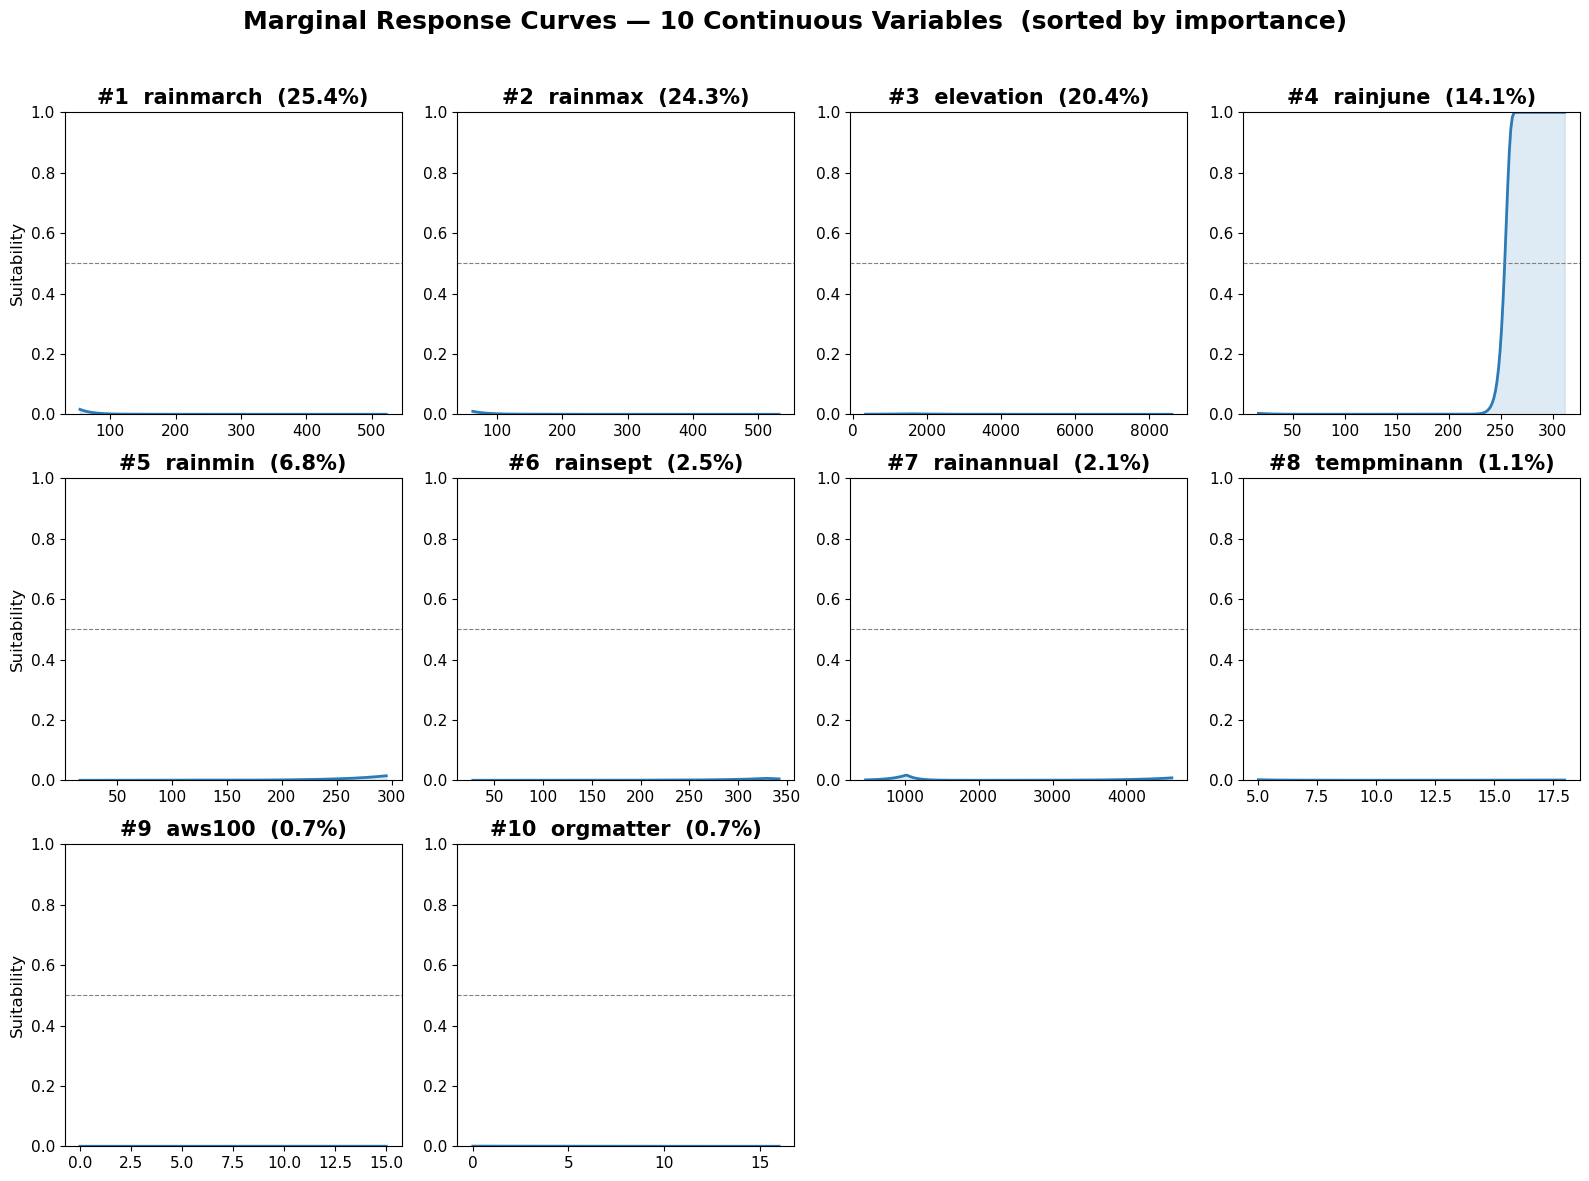

In [24]:
# ── Marginal response curves — continuous variables sorted by importance ────────

imp_df_cont = imp_df_t[~imp_df_t["Variable"].isin(CATEGORICAL_LAYERS)].reset_index(drop=True)
n_vars      = len(imp_df_cont)
n_cols      = 4
n_rows      = -(-n_vars // n_cols)   # ceiling division → 3 rows for 11 variables
X_mean      = X_train_t[BEST_VARS].mean()

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4), squeeze=False)
axes_flat  = axes.ravel()

rank = 0
for _, row in imp_df_cont.iterrows():
    var  = row["Variable"]
    x_lo = X_train_t[var].quantile(0.05)
    x_hi = X_train_t[var].quantile(0.95)

    # Skip variables with effectively no variation in the training data
    if x_hi <= x_lo:
        axes_flat[rank].set_visible(False)
        rank += 1
        continue

    ax     = axes_flat[rank]
    x_vals = np.linspace(x_lo, x_hi, 200)
    X_rc   = pd.DataFrame(np.tile(X_mean.values, (200, 1)), columns=BEST_VARS)
    X_rc[var] = x_vals
    suit   = tuned_model.predict(X_rc)

    ax.fill_between(x_vals, suit, alpha=0.15, color="#2c7bb6")
    ax.plot(x_vals, suit, lw=2.0, color="#2c7bb6")
    ax.axhline(0.5, color="gray", ls="--", lw=0.8)
    ax.set_ylim(0, 1)
    ax.set_title(f"#{rank + 1}  {var}  ({row['Importance (%)']:.1f}%)", fontsize=15, fontweight="bold")
    if rank % n_cols == 0:
        ax.set_ylabel("Suitability", fontsize=12)
    ax.tick_params(labelsize=11)
    rank += 1

for j in range(rank, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle(f"Marginal Response Curves — {n_vars} Continuous Variables  (sorted by importance)",
             fontsize=18, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 4.5 Generate Tuned Prediction Raster

Tuned suitability raster saved → MaxEnt_Tuned/tuned_suitability.tif


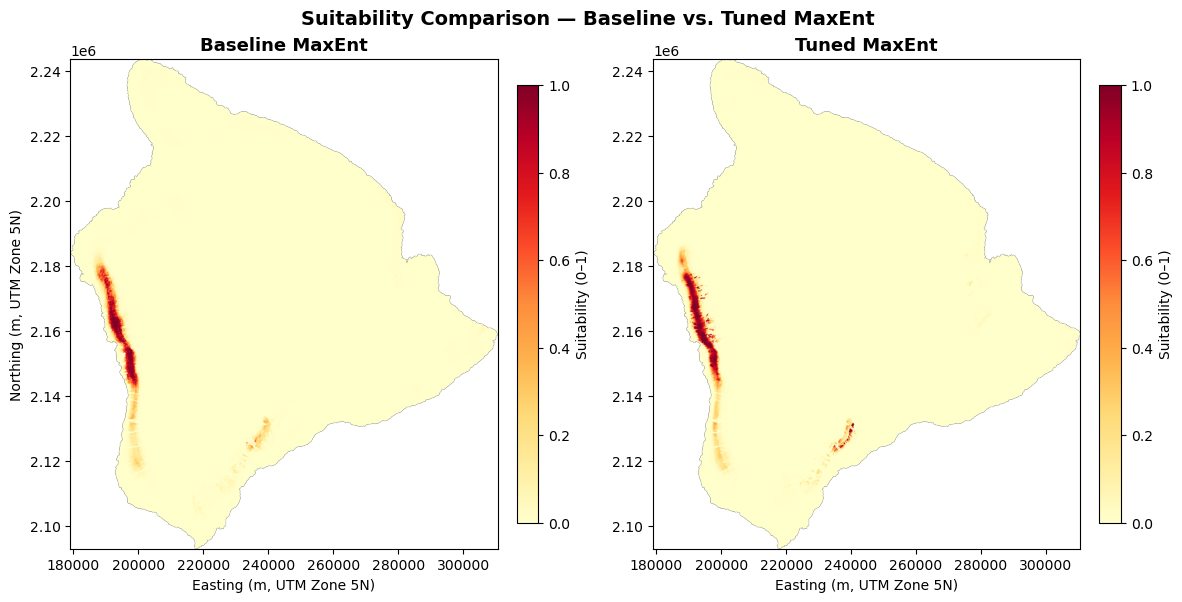

In [25]:
# ── Apply tuned model (cloglog) to the raster stack ───────────────────────────
tuned_raster = os.path.join(TUNED_OUTPUT_DIR, "tuned_suitability.tif")

# tuned_raster_list is ordered to match BEST_VARS so elapid reads only those layers
elapid.apply_model_to_rasters(
    tuned_model, tuned_raster_list, output_path=tuned_raster, quiet=True,
)
print(f"Tuned suitability raster saved → {tuned_raster}")

with rasterio.open(tuned_raster) as src:
    suit_t   = src.read(1).astype(float)
    suit_nd  = src.nodata
    suit_bnd = src.bounds
suit_t = np.where(suit_t == suit_nd, np.nan, suit_t)

# ── Side-by-side comparison: baseline vs. tuned ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, arr, bnd, title in [
    (axes[0], suit_arr, suit_bounds, "Baseline MaxEnt"),
    (axes[1], suit_t,   suit_bnd,    "Tuned MaxEnt"),
]:
    im = ax.imshow(
        arr, cmap="YlOrRd", vmin=0, vmax=1,
        extent=[bnd.left, bnd.right, bnd.bottom, bnd.top],
        origin="upper", aspect="equal",
    )
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Suitability (0–1)")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Easting (m, UTM Zone 5N)")
    ax.ticklabel_format(useOffset=False)

axes[0].set_ylabel("Northing (m, UTM Zone 5N)")
fig.suptitle("Suitability Comparison — Baseline vs. Tuned MaxEnt", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Compared to the baseline, the tuned map shows a more spatially concentrated high-suitability core in the Kona belt and less diffuse moderate-suitability area in rain-shadow zones. This result reflects the combined effect of hinge/product features capturing threshold responses and higher regularization suppressing peripheral predictions.

### 4.6 Effect of Output Transform

  raw       → MaxEnt_Tuned/suitability_raw.tif
  cloglog   → MaxEnt_Tuned/tuned_suitability.tif  (reused from Section 4.5)


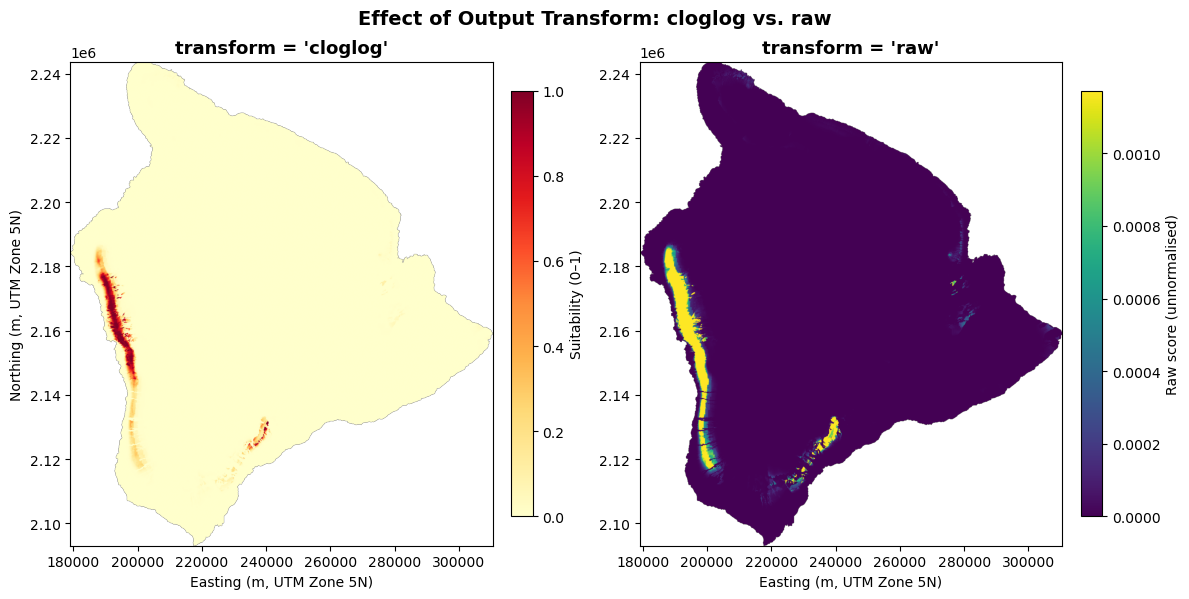

In [26]:
# ── Compare output transforms: cloglog vs. raw ────────────────────────────────
# cloglog: reuse tuned_model and its raster from Section 4.5 (no re-fit needed)
# raw:     fit one new model with transform='raw'

m_raw    = elapid.MaxentModel(
    feature_types   = BEST_FEATURES,
    transform       = "raw",
    beta_multiplier = BEST_BETA,
)
m_raw.fit(X_train_t, y_train_t, categorical=cat_indices_t, labels=BEST_VARS)
raw_raster = os.path.join(TUNED_OUTPUT_DIR, "suitability_raw.tif")
elapid.apply_model_to_rasters(m_raw, tuned_raster_list, output_path=raw_raster, quiet=True)
print(f"  raw       → {raw_raster}")
print(f"  cloglog   → {tuned_raster}  (reused from Section 4.5)")

# ── Side-by-side maps ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, raster_path, tr in [
    (axes[0], tuned_raster, "cloglog"),
    (axes[1], raw_raster,   "raw"),
]:
    with rasterio.open(raster_path) as src:
        arr    = src.read(1).astype(float)
        nd     = src.nodata
        bounds = src.bounds
    arr   = np.where(arr == nd, np.nan, arr)
    valid = arr[~np.isnan(arr)]

    if tr == "raw":
        v0, v1 = np.percentile(valid, [2, 98])   # clip extremes so spatial pattern is visible
        cmap_  = "viridis"
        clabel = "Raw score (unnormalised)"
    else:
        v0, v1 = 0, 1
        cmap_  = "YlOrRd"
        clabel = "Suitability (0–1)"

    im = ax.imshow(
        arr, cmap=cmap_, vmin=v0, vmax=v1,
        extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
        origin="upper", aspect="equal",
    )
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=clabel)
    ax.set_title(f"transform = '{tr}'", fontsize=13, fontweight="bold")
    ax.set_xlabel("Easting (m, UTM Zone 5N)")
    ax.ticklabel_format(useOffset=False)

axes[0].set_ylabel("Northing (m, UTM Zone 5N)")
fig.suptitle("Effect of Output Transform: cloglog vs. raw", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


Both transforms preserve the same spatial pattern, but the raw output lacks a fixed scale; cloglog rescales scores to [0, 1] with a calibrated occurrence-probability interpretation, making it more suitable for thresholding or cross-study comparison.

# 5. Key Takeaways, Limitations, and References

## 5.1 Key Takeaways

**Parameter choices in MaxEnt have measurable effects on model performance.** Grid search over feature classes, regularization, background size, and variable subsets identified a configuration that improved test AUC relative to the baseline.

**Coffee suitability on Hawaii Island is driven primarily by elevation and seasonal rainfall.** Permutation importance consistently ranked these variables at the top, which consistent with Kona coffee's agroclimatic profile.

**AUC alone is insufficient; response curves are essential.** High discriminative performance does not guarantee ecologically meaningful predictions. Cross-checking model outputs against domain knowledge should be standard practice in any MaxEnt workflow.

## 5.2 Limitations

**Presence points reflect cultivation history, not environmental potential.** The 6,014 records encode decades of land-access and market decisions; environmentally suitable but un-planted terrain is under-represented in the training signal.

**Climate layers are historical averages.** Temperature data span 1971-2000 and rainfall data span 1978-2007. The suitability surface describes past conditions and should not be interpreted as current or future projections without replacing these predictors.

**cloglog output is relative suitability, not calibrated probability.** Cross-model or cross-species score comparisons require additional normalization that this notebook does not perform.

## 5.3 References

**Data sources**

- Melrose, J., & Delparte, D. (2012). *Hawaii County Food Self-Sufficiency Baseline 2012.* Department of Geography and Environmental Studies, University of Hawaii at Hilo.
- Kemp, K. K. (2012). *The Hawai'i Island Crop Probability Map: An Update of the Crop Growth Parameters for the Hawaii County Crop Model.* Los Angeles: USC GIS Research Lab (now the Spatial Sciences Institute).

**Software**

- Anderson, C. B. (2023). elapid: Species distribution modeling tools for Python. *Journal of Open Source Software*, 8(84), 4930. https://doi.org/10.21105/joss.04930